C:\Users\tomos\AppData\Local\Temp\ipykernel_38768\2099282134.py:13: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


Figure saved to: C:\Users\tomos\OneDrive - Ulster University\GlacialExtractionData\scripts\figure_scripts\Figure10\Figure10.png


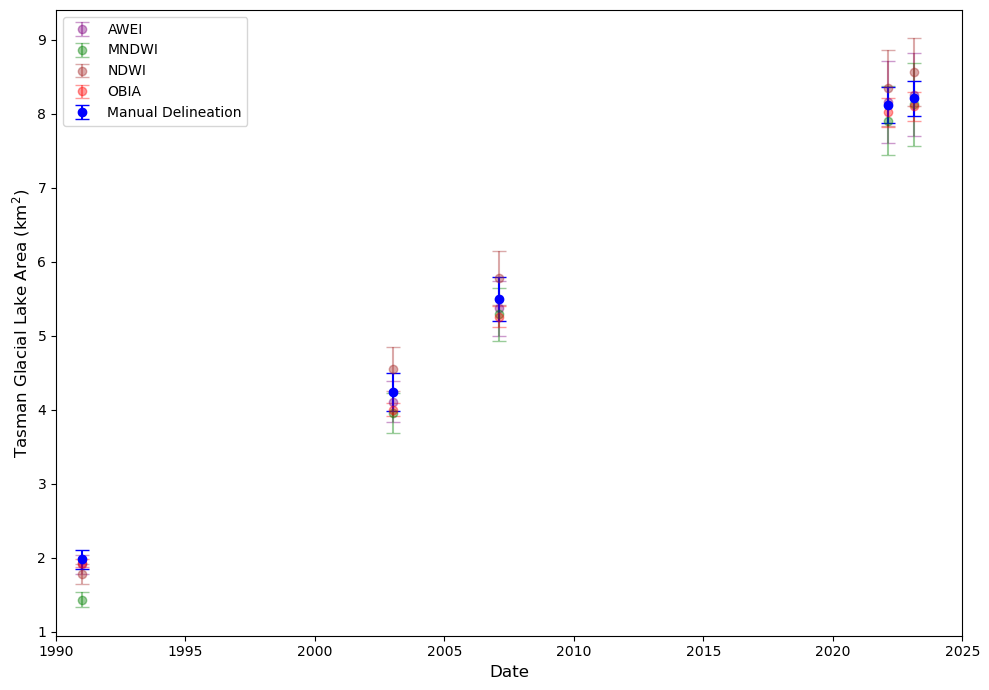

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

base_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

file_path = os.path.join(base_dir, "IndexTableResults.csv")
save_path = os.path.join(base_dir, "Figure10.png")

df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"])

fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(df["Date"], df["AWEI"], yerr=df["AWEI_error"],
            fmt='o', capsize=5, label='AWEI', color='purple', alpha=0.4)

ax.errorbar(df["Date"], df["MNDWI"], yerr=df["MNDWI_error"],
            fmt='o', capsize=5, label='MNDWI', color='green', alpha=0.4)

ax.errorbar(df["Date"], df["NDWI"], yerr=df["NDWI_error"],
            fmt='o', capsize=5, label='NDWI', color='brown', alpha=0.4)

ax.errorbar(df["Date"], df["OBIA"], yerr=df["OBIA_error"],
            fmt='o', capsize=5, label='OBIA', color='red', alpha=0.4)

ax.errorbar(df["Date"], df["MD"], yerr=df["MD_error"],
            fmt='o', capsize=5, label='Manual Delineation', color='blue', alpha=1.0)

ax.set_xlim(pd.Timestamp('1990-01-01'), pd.Timestamp('2025-01-01'))

years = list(range(1990, 2026, 5))
ax.set_xticks([pd.Timestamp(f"{year}-01-01") for year in years])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Tasman Glacial Lake Area (km$^2$)', fontsize=12)

ax.legend()

plt.tight_layout()

fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {save_path}")

plt.show()
plt.close(fig)